In [1]:
# 🔹 Basic Libraries
import pandas as pd
import numpy as np

# 🔹 Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 🔹 Train-Test Split
from sklearn.model_selection import train_test_split

# 🔹 Models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 🔹 Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 🔹 Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🔹 Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
# Load Excel file
df = pd.read_excel("DF4_Mag_Windowed.xlsx")

# View first rows
df.head()

,M1_min,M1_max,M1_mean,M1_std,M1_var,M1_rms,M1_mav,M2_min,M2_max,M2_mean,...,M8_mean,M8_std,M8_var,M8_rms,M8_mav,Amplitude,Condition,Level,FileName,Window
0,0.000318,0.000719,0.000504,0.000067,4.518371e-09,0.000509,0.000504,0.000178,0.000438,0.000315,...,0.000221,0.000031,9.509918e-10,0.000224,0.000221,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1,1
1,0.000311,0.000705,0.000504,0.000067,4.536946e-09,0.000508,0.000504,0.000199,0.000433,0.000318,...,0.000219,0.000031,9.380120e-10,0.000221,0.000219,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1,2
2,0.000301,0.000705,0.000506,0.000068,4.586399e-09,0.000511,0.000506,0.000202,0.000432,0.000318,...,0.000224,0.000030,9.082154e-10,0.000226,0.000224,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1,3
3,0.000314,0.000729,0.000509,0.000068,4.614998e-09,0.000514,0.000509,0.000204,0.000439,0.000317,...,0.000224,0.000030,9.027684e-10,0.000226,0.000224,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1,4
4,0.000316,0.000713,0.000506,0.000067,4.547360e-09,0.000510,0.000506,0.000201,0.000445,0.000318,...,0.000223,0.000030,9.092050e-10,0.000225,0.000223,0.5,6Nm,1,0.5amp-6Nm-lev1-EXP1,5


In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (8190, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 61 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   M1_min     8190 non-null   float64
 1   M1_max     8190 non-null   float64
 2   M1_mean    8190 non-null   float64
 3   M1_std     8190 non-null   float64
 4   M1_var     8190 non-null   float64
 5   M1_rms     8190 non-null   float64
 6   M1_mav     8190 non-null   float64
 7   M2_min     8190 non-null   float64
 8   M2_max     8190 non-null   float64
 9   M2_mean    8190 non-null   float64
 10  M2_std     8190 non-null   float64
 11  M2_var     8190 non-null   float64
 12  M2_rms     8190 non-null   float64
 13  M2_mav     8190 non-null   float64
 14  M3_min     8190 non-null   float64
 15  M3_max     8190 non-null   float64
 16  M3_mean    8190 non-null   float64
 17  M3_std     8190 non-null   float64
 18  M3_var     8190 non-null   float64
 19  M3_rms     8190 non-null   flo

,M1_min,M1_max,M1_mean,M1_std,M1_var,M1_rms,M1_mav,M2_min,M2_max,M2_mean,...,M8_min,M8_max,M8_mean,M8_std,M8_var,M8_rms,M8_mav,Amplitude,Level,Window
count,8190.000000,8190.000000,8190.000000,8190.000000,8.190000e+03,8190.000000,8190.000000,8190.000000,8190.000000,8190.000000,...,8190.000000,8190.000000,8190.000000,8190.000000,8.190000e+03,8190.000000,8190.000000,8190.000000,8190.000000,8190.00000
mean,0.000140,0.001054,0.000522,0.000147,2.521780e-08,0.000545,0.000522,0.000125,0.000546,0.000327,...,0.000072,0.000397,0.000221,0.000050,2.767670e-09,0.000227,0.000221,1.166667,2.307692,15.50000
std,0.000102,0.000277,0.000037,0.000060,1.628687e-08,0.000048,0.000037,0.000062,0.000092,0.000010,...,0.000036,0.000076,0.000011,0.000018,1.899868e-09,0.000013,0.000011,0.623648,1.264052,8.65597
min,0.000002,0.000593,0.000403,0.000063,4.009891e-09,0.000408,0.000403,0.000006,0.000413,0.000300,...,0.000002,0.000281,0.000187,0.000026,6.659022e-10,0.000190,0.000187,0.500000,0.000000,1.00000
25%,0.000054,0.000718,0.000500,0.000068,4.604286e-09,0.000512,0.000500,0.000055,0.000454,0.000319,...,0.000038,0.000326,0.000215,0.000031,9.317016e-10,0.000220,0.000215,0.500000,1.000000,8.00000
50%,0.000097,0.001128,0.000526,0.000166,2.739331e-08,0.000551,0.000526,0.000143,0.000531,0.000327,...,0.000075,0.000386,0.000221,0.000047,2.218415e-09,0.000226,0.000221,1.000000,2.000000,15.50000
75%,0.000257,0.001250,0.000550,0.000196,3.858087e-08,0.000581,0.000550,0.000181,0.000629,0.000335,...,0.000101,0.000455,0.000228,0.000066,4.297288e-09,0.000235,0.000228,2.000000,3.000000,23.00000
max,0.000336,0.001745,0.000604,0.000248,6.129529e-08,0.000646,0.000604,0.000230,0.000828,0.000365,...,0.000148,0.000701,0.000289,0.000124,1.525342e-08,0.000314,0.000289,2.000000,4.000000,30.00000


In [4]:
df.drop(columns=["FileName", "Window"],inplace=True)

In [5]:
df.head()

,M1_min,M1_max,M1_mean,M1_std,M1_var,M1_rms,M1_mav,M2_min,M2_max,M2_mean,...,M8_min,M8_max,M8_mean,M8_std,M8_var,M8_rms,M8_mav,Amplitude,Condition,Level
0,0.000318,0.000719,0.000504,0.000067,4.518371e-09,0.000509,0.000504,0.000178,0.000438,0.000315,...,0.000105,0.000329,0.000221,0.000031,9.509918e-10,0.000224,0.000221,0.5,6Nm,1
1,0.000311,0.000705,0.000504,0.000067,4.536946e-09,0.000508,0.000504,0.000199,0.000433,0.000318,...,0.000112,0.000319,0.000219,0.000031,9.380120e-10,0.000221,0.000219,0.5,6Nm,1
2,0.000301,0.000705,0.000506,0.000068,4.586399e-09,0.000511,0.000506,0.000202,0.000432,0.000318,...,0.000102,0.000333,0.000224,0.000030,9.082154e-10,0.000226,0.000224,0.5,6Nm,1
3,0.000314,0.000729,0.000509,0.000068,4.614998e-09,0.000514,0.000509,0.000204,0.000439,0.000317,...,0.000127,0.000337,0.000224,0.000030,9.027684e-10,0.000226,0.000224,0.5,6Nm,1
4,0.000316,0.000713,0.000506,0.000067,4.547360e-09,0.000510,0.000506,0.000201,0.000445,0.000318,...,0.000123,0.000311,0.000223,0.000030,9.092050e-10,0.000225,0.000223,0.5,6Nm,1


<Axes: >

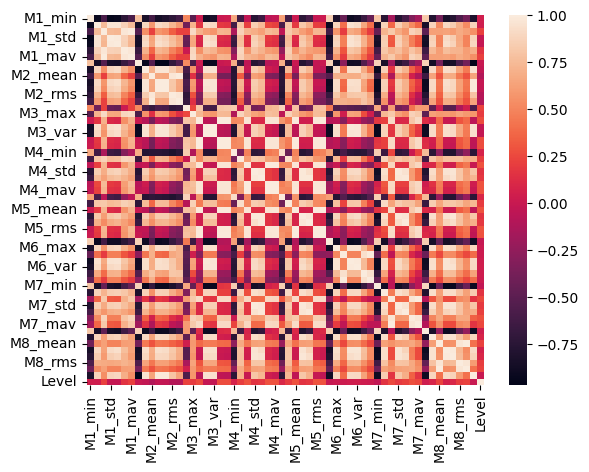

In [6]:
sns.heatmap(df.drop(columns=["Condition"]).corr())

In [7]:
df["Target"] = df["Condition"] + "_L" + df["Level"].astype(str)

In [8]:
# Drop unnecessary columns
X = df.drop(columns=["Condition", "Level", "Target"])

# Target
y = df["Target"]

print("Features shape:", X.shape)

Features shape: (8190, 57)


In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['6Nm_L1' '6Nm_L2' '6Nm_L3' '6Nm_L4' '9Nm_L1' '9Nm_L2' '9Nm_L3' '9Nm_L4'
 'Healthy_L0' 'NoBolt_L1' 'NoBolt_L2' 'NoBolt_L3' 'NoBolt_L4']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
models = {
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")

    # Use scaled data for SVM, others can also use scaled safely
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")


🔹 Training SVM...
SVM Accuracy: 0.9670

🔹 Training Decision Tree...
Decision Tree Accuracy: 0.9298

🔹 Training Random Forest...
Random Forest Accuracy: 0.9805

🔹 Training Gradient Boosting...
Gradient Boosting Accuracy: 0.9744

🔹 Training XGBoost...


C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:50:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9805


In [13]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

               Model  Accuracy
2      Random Forest  0.980464
4            XGBoost  0.980464
3  Gradient Boosting  0.974359
0                SVM  0.967033
1      Decision Tree  0.929792


In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")

y_pred = best_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       126
           1       0.98      0.98      0.98       126
           2       0.91      0.93      0.92       126
           3       0.93      0.91      0.92       126
           4       0.99      0.99      0.99       126
           5       0.98      0.98      0.98       126
           6       0.99      1.00      1.00       126
           7       1.00      0.99      1.00       126
           8       1.00      1.00      1.00       126
           9       1.00      0.98      0.99       126
          10       0.98      0.99      0.98       126
          11       1.00      0.99      1.00       126
          12       1.00      1.00      1.00       126

    accuracy                           0.98      1638
   macro avg       0.98      0.98      0.98      1638
weighted avg       0.98      0.98      0.98      1638



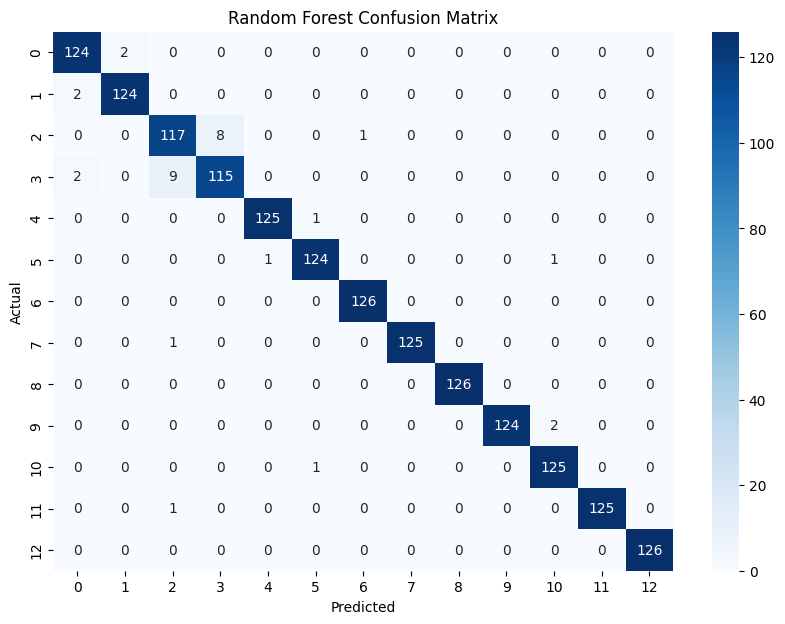

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_model_name} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_values = [100, 200, 300]
depth_values = [5, 10, 20]

results = []

for n in n_values:
    for d in depth_values:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=d,
            random_state=42
        )
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        
        results.append([n, d, acc])

df_plot = pd.DataFrame(results, columns=["n_estimators", "max_depth", "accuracy"])

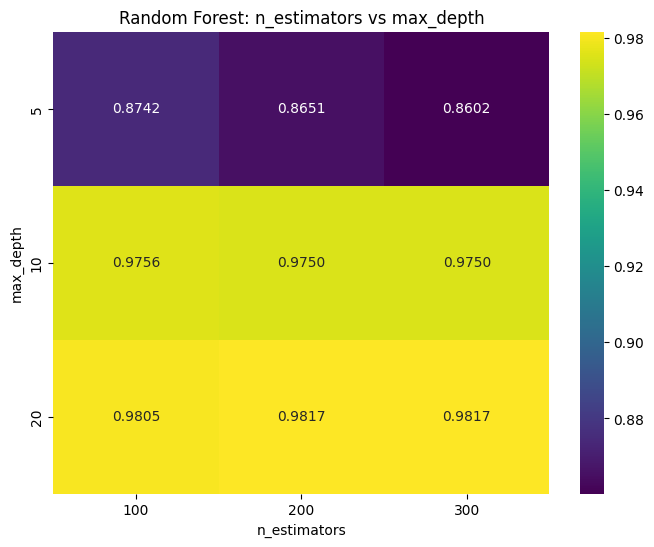

In [17]:
pivot = df_plot.pivot(index="max_depth", columns="n_estimators", values="accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".4f")

plt.title("Random Forest: n_estimators vs max_depth")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")

plt.show()

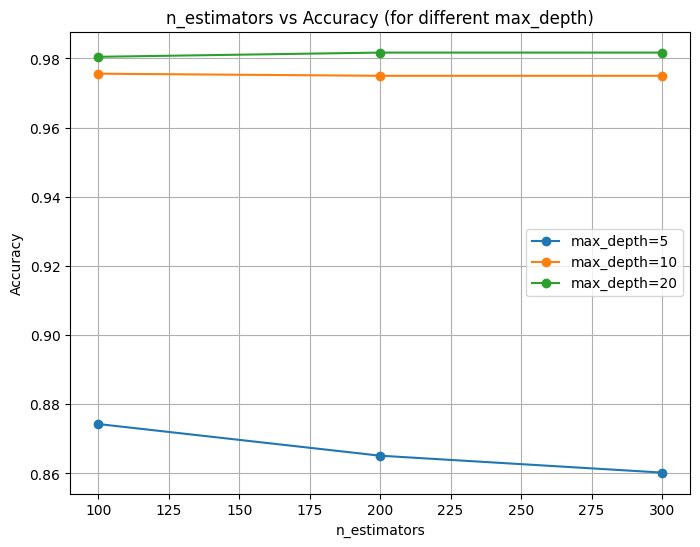

In [18]:
plt.figure(figsize=(8,6))

# Loop over max_depth values (each line)
for d in sorted(df_plot["max_depth"].unique()):
    
    subset = df_plot[df_plot["max_depth"] == d]
    
    plt.plot(
        subset["n_estimators"],
        subset["accuracy"],
        marker='o',
        label=f"max_depth={d}"
    )

plt.title("n_estimators vs Accuracy (for different max_depth)")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

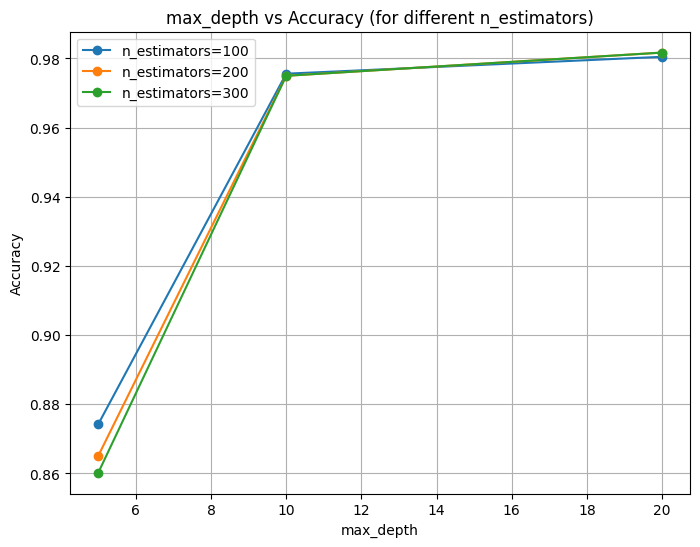

In [19]:
plt.figure(figsize=(8,6))

for n in sorted(df_plot["n_estimators"].unique()):
    
    subset = df_plot[df_plot["n_estimators"] == n]
    
    plt.plot(
        subset["max_depth"],
        subset["accuracy"],
        marker='o',
        label=f"n_estimators={n}"
    )

plt.title("max_depth vs Accuracy (for different n_estimators)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [20]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Unique values
n_vals = sorted(df_plot["n_estimators"].unique())
d_vals = sorted(df_plot["max_depth"].unique())

# Create meshgrid
N, D = np.meshgrid(n_vals, d_vals)

# Create Z (accuracy matrix)
Z = np.zeros_like(N, dtype=float)

for i in range(len(d_vals)):
    for j in range(len(n_vals)):
        val = df_plot[
            (df_plot["n_estimators"] == N[i, j]) &
            (df_plot["max_depth"] == D[i, j])
        ]["accuracy"].values
        
        if len(val) > 0:
            Z[i, j] = val[0]

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3, 3) and arg 2 with shape (2, 2).

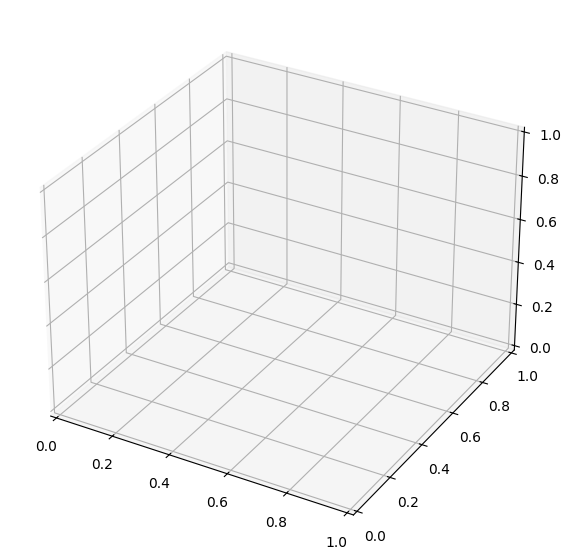

In [62]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(N, D, Z)

ax.set_xlabel("n_estimators")
ax.set_ylabel("max_depth")
ax.set_zlabel("Accuracy")

plt.title("3D Surface Plot: RF Hyperparameters")

plt.show()

In [ ]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(N, D, Z, cmap='viridis')

fig.colorbar(surf, shrink=0.5, aspect=5)

ax.set_xlabel("n_estimators")
ax.set_ylabel("max_depth")
ax.set_zlabel("Accuracy")

plt.title("3D Surface Plot with Color")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

# Loop over max_depth values (each line)
for d in sorted(df_plot["max_depth"].unique()):
    
    subset = df_plot[df_plot["max_depth"] == d]
    
    plt.plot(
        subset["n_estimators"],
        subset["accuracy"],
        marker='o',
        label=f"max_depth={d}"
    )

plt.title("n_estimators vs Accuracy (for different max_depth)")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for n in sorted(df_plot["n_estimators"].unique()):
    
    subset = df_plot[df_plot["n_estimators"] == n]
    
    plt.plot(
        subset["max_depth"],
        subset["accuracy"],
        marker='o',
        label=f"n_estimators={n}"
    )

plt.title("max_depth vs Accuracy (for different n_estimators)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd
import numpy as np

C_values = [0.1, 1, 10, 50]
gamma_values = ['scale', 'auto']

results = []

for c in C_values:
    for g in gamma_values:
        
        model = SVC(C=c, gamma=g, kernel='rbf')
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        
        results.append([c, g, acc])

df_svm_plot = pd.DataFrame(results, columns=["C", "gamma", "accuracy"])

In [ ]:
pivot = df_svm_plot.pivot(index="gamma", columns="C", values="accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".4f")

plt.title("SVM: C vs Gamma")
plt.xlabel("C")
plt.ylabel("Gamma")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for g in gamma_values:
    subset = df_svm_plot[df_svm_plot["gamma"] == g]
    
    plt.plot(
        subset["C"],
        subset["accuracy"],
        marker='o',
        label=f"gamma={g}"
    )

plt.title("C vs Accuracy (for different gamma)")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for c in C_values:
    subset = df_svm_plot[df_svm_plot["C"] == c]
    
    plt.plot(
        subset["gamma"],
        subset["accuracy"],
        marker='o',
        label=f"C={c}"
    )

plt.title("Gamma vs Accuracy (for different C)")
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
gamma_map = {'scale': 0, 'auto': 1}
df_svm_plot["gamma_num"] = df_svm_plot["gamma"].map(gamma_map)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

C_vals = sorted(df_svm_plot["C"].unique())
G_vals = sorted(df_svm_plot["gamma_num"].unique())

C_grid, G_grid = np.meshgrid(C_vals, G_vals)
Z = np.zeros_like(C_grid, dtype=float)

for i in range(len(G_vals)):
    for j in range(len(C_vals)):
        val = df_svm_plot[
            (df_svm_plot["C"] == C_grid[i, j]) &
            (df_svm_plot["gamma_num"] == G_grid[i, j])
        ]["accuracy"].values
        
        if len(val) > 0:
            Z[i, j] = val[0]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(C_grid, G_grid, Z, cmap='viridis')

ax.set_xlabel("C")
ax.set_ylabel("Gamma (0=scale,1=auto)")
ax.set_zlabel("Accuracy")

plt.title("SVM 3D Surface")

plt.show()

In [ ]:
import pandas as pd
import numpy as np

depth_values = [5, 10, 20, None]
split_values = [2, 5, 10]

results = []

for d in depth_values:
    for s in split_values:
        
        model = DecisionTreeClassifier(
            max_depth=d,
            min_samples_split=s,
            random_state=42
        )
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        
        results.append([d, s, acc])

df_dt_plot = pd.DataFrame(results, columns=["max_depth", "min_samples_split", "accuracy"])

In [ ]:
df_dt_plot["max_depth"] = df_dt_plot["max_depth"].astype(str)

pivot = df_dt_plot.pivot(index="min_samples_split", columns="max_depth", values="accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".4f")

plt.title("Decision Tree: max_depth vs min_samples_split")
plt.xlabel("max_depth")
plt.ylabel("min_samples_split")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for s in split_values:
    subset = df_dt_plot[df_dt_plot["min_samples_split"] == s]
    
    plt.plot(
        subset["max_depth"],
        subset["accuracy"],
        marker='o',
        label=f"min_samples_split={s}"
    )

plt.title("max_depth vs Accuracy (for different min_samples_split)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

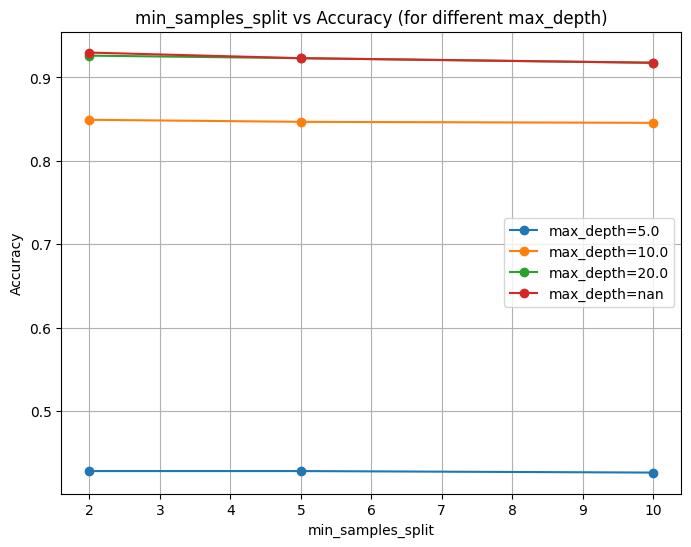

In [43]:
plt.figure(figsize=(8,6))

for d in df_dt_plot["max_depth"].unique():
    subset = df_dt_plot[df_dt_plot["max_depth"] == d]
    
    plt.plot(
        subset["min_samples_split"],
        subset["accuracy"],
        marker='o',
        label=f"max_depth={d}"
    )

plt.title("min_samples_split vs Accuracy (for different max_depth)")
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [44]:
depth_map = {str(v): i for i, v in enumerate(df_dt_plot["max_depth"].unique())}
df_dt_plot["depth_num"] = df_dt_plot["max_depth"].map(depth_map)

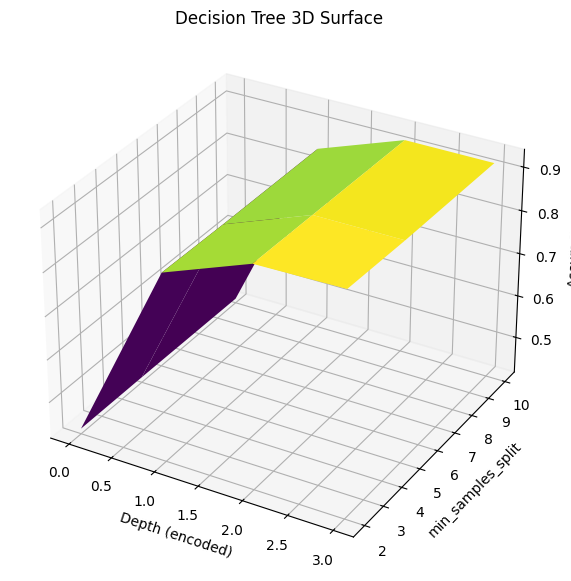

In [45]:
from mpl_toolkits.mplot3d import Axes3D

D_vals = sorted(df_dt_plot["depth_num"].unique())
S_vals = sorted(df_dt_plot["min_samples_split"].unique())

D_grid, S_grid = np.meshgrid(D_vals, S_vals)
Z = np.zeros_like(D_grid, dtype=float)

for i in range(len(S_vals)):
    for j in range(len(D_vals)):
        val = df_dt_plot[
            (df_dt_plot["depth_num"] == D_grid[i, j]) &
            (df_dt_plot["min_samples_split"] == S_grid[i, j])
        ]["accuracy"].values
        
        if len(val) > 0:
            Z[i, j] = val[0]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(D_grid, S_grid, Z, cmap='viridis')

ax.set_xlabel("Depth (encoded)")
ax.set_ylabel("min_samples_split")
ax.set_zlabel("Accuracy")

plt.title("Decision Tree 3D Surface")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for lr in sorted(df_gb_plot["learning_rate"].unique()):
    subset = df_gb_plot[df_gb_plot["learning_rate"] == lr]
    
    plt.plot(
        subset["n_estimators"],
        subset["accuracy"],
        marker='o',
        label=f"lr={lr}"
    )

plt.title("n_estimators vs Accuracy (for different learning_rate)")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for n in sorted(df_gb_plot["n_estimators"].unique()):
    subset = df_gb_plot[df_gb_plot["n_estimators"] == n]
    
    plt.plot(
        subset["learning_rate"],
        subset["accuracy"],
        marker='o',
        label=f"n={n}"
    )

plt.title("learning_rate vs Accuracy (for different n_estimators)")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

N_vals = sorted(df_gb_plot["n_estimators"].unique())
LR_vals = sorted(df_gb_plot["learning_rate"].unique())

N_grid, LR_grid = np.meshgrid(N_vals, LR_vals)
Z = np.zeros_like(N_grid, dtype=float)

for i in range(len(LR_vals)):
    for j in range(len(N_vals)):
        val = df_gb_plot[
            (df_gb_plot["n_estimators"] == N_grid[i, j]) &
            (df_gb_plot["learning_rate"] == LR_grid[i, j])
        ]["accuracy"].values
        
        if len(val) > 0:
            Z[i, j] = val[0]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(N_grid, LR_grid, Z, cmap='viridis')

ax.set_xlabel("n_estimators")
ax.set_ylabel("learning_rate")
ax.set_zlabel("Accuracy")

plt.title("Gradient Boosting 3D Surface")

plt.show()

In [46]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 🔥 Reduced but effective values
n_values = [100, 200]
lr_values = [0.05, 0.1]

results = []

for n in n_values:
    for lr in lr_values:
        
        model = XGBClassifier(
            n_estimators=n,
            learning_rate=lr,
            max_depth=5,        # good default
            subsample=0.8,      # faster + prevents overfitting
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            use_label_encoder=False,
            n_jobs=-1           # 🔥 parallel processing
        )
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        
        results.append([n, lr, acc])

df_xgb_plot = pd.DataFrame(results, columns=["n_estimators", "learning_rate", "accuracy"])

print(df_xgb_plot)

C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:00:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:00:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:00:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:00:46] WARNING: C:\a

   n_estimators  learning_rate  accuracy
0           100           0.05  0.976190
1           100           0.10  0.978022
2           200           0.05  0.979853
3           200           0.10  0.979853


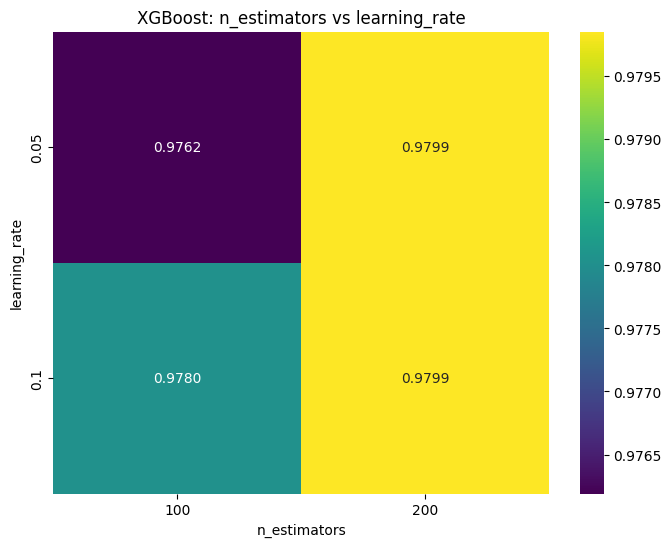

In [47]:
pivot = df_xgb_plot.pivot(index="learning_rate", columns="n_estimators", values="accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".4f")

plt.title("XGBoost: n_estimators vs learning_rate")
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")

plt.show()

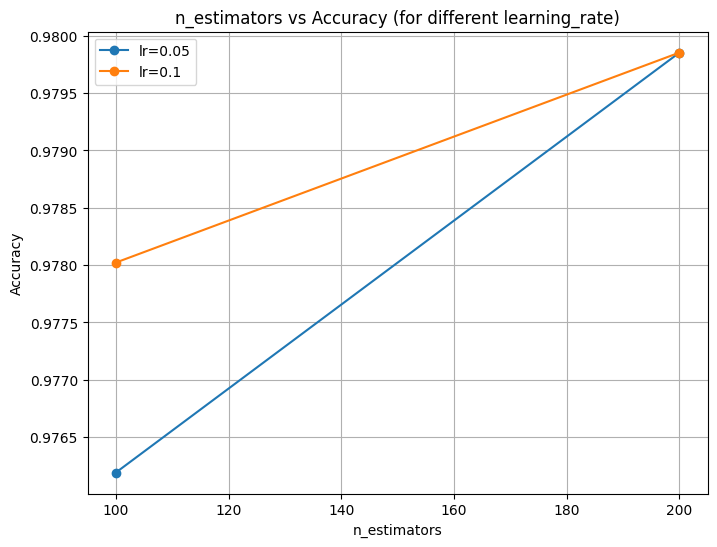

In [48]:
plt.figure(figsize=(8,6))

for lr in sorted(df_xgb_plot["learning_rate"].unique()):
    subset = df_xgb_plot[df_xgb_plot["learning_rate"] == lr]
    
    plt.plot(
        subset["n_estimators"],
        subset["accuracy"],
        marker='o',
        label=f"lr={lr}"
    )

plt.title("n_estimators vs Accuracy (for different learning_rate)")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

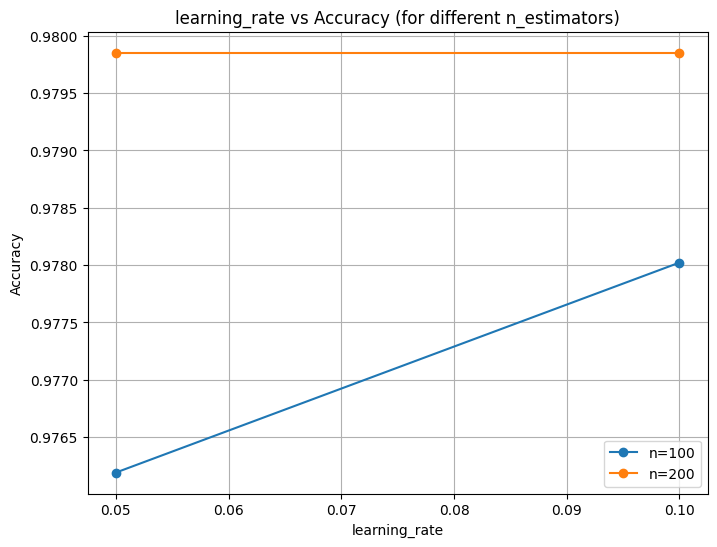

In [49]:
plt.figure(figsize=(8,6))

for n in sorted(df_xgb_plot["n_estimators"].unique()):
    subset = df_xgb_plot[df_xgb_plot["n_estimators"] == n]
    
    plt.plot(
        subset["learning_rate"],
        subset["accuracy"],
        marker='o',
        label=f"n={n}"
    )

plt.title("learning_rate vs Accuracy (for different n_estimators)")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

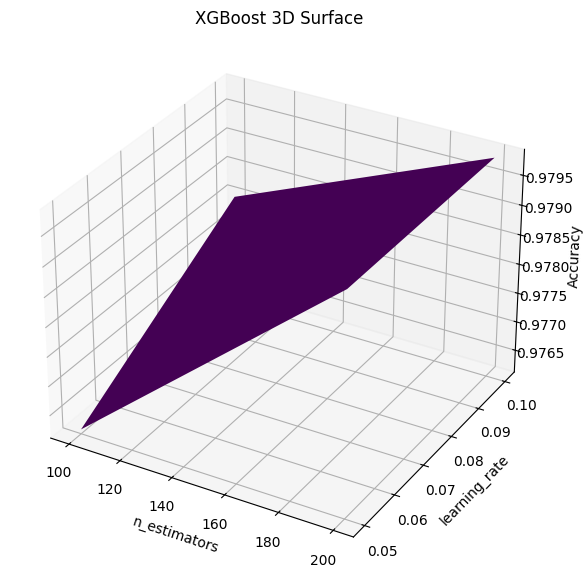

In [50]:
from mpl_toolkits.mplot3d import Axes3D

N_vals = sorted(df_xgb_plot["n_estimators"].unique())
LR_vals = sorted(df_xgb_plot["learning_rate"].unique())

N_grid, LR_grid = np.meshgrid(N_vals, LR_vals)
Z = np.zeros_like(N_grid, dtype=float)

for i in range(len(LR_vals)):
    for j in range(len(N_vals)):
        val = df_xgb_plot[
            (df_xgb_plot["n_estimators"] == N_grid[i, j]) &
            (df_xgb_plot["learning_rate"] == LR_grid[i, j])
        ]["accuracy"].values
        
        if len(val) > 0:
            Z[i, j] = val[0]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(N_grid, LR_grid, Z, cmap='viridis')

ax.set_xlabel("n_estimators")
ax.set_ylabel("learning_rate")
ax.set_zlabel("Accuracy")

plt.title("XGBoost 3D Surface")

plt.show()

In [54]:
new_data = prepare_df4_for_prediction("experiment_8-1.csv")

print(new_data.shape)
print(new_data.head())

(30, 57)
     M1_min    M1_max   M1_mean    M1_std        M1_var    M1_rms    M1_mav  \
0  0.000284  0.000712  0.000507  0.000067  4.502269e-09  0.000511  0.000507   
1  0.000257  0.000753  0.000506  0.000067  4.500945e-09  0.000511  0.000506   
2  0.000278  0.000749  0.000506  0.000068  4.571965e-09  0.000510  0.000506   
3  0.000287  0.000714  0.000505  0.000066  4.396851e-09  0.000509  0.000505   
4  0.000286  0.000708  0.000504  0.000067  4.551201e-09  0.000508  0.000504   

     M2_min    M2_max   M2_mean  ...    M7_rms    M7_mav    M8_min    M8_max  \
0  0.000193  0.000437  0.000316  ...  0.000350  0.000348  0.000121  0.000334   
1  0.000174  0.000473  0.000320  ...  0.000348  0.000346  0.000120  0.000343   
2  0.000185  0.000442  0.000320  ...  0.000348  0.000347  0.000128  0.000335   
3  0.000180  0.000439  0.000319  ...  0.000350  0.000349  0.000095  0.000311   
4  0.000189  0.000439  0.000315  ...  0.000355  0.000353  0.000107  0.000329   

    M8_mean   M8_std        M8_var 

In [57]:
new_data["Amplitude"]=0.5